# Bayesian experimental design with flow matching

This notebook trains the conditional flow-matching density model first, then trains a recurrent policy. The policy reads a history of `(y, x, eps)` and proposes the next experiment `eps`.

The policy objective below is likelihood-based: it maximizes the learned likelihood of a target observation under the proposed experiment. The differentiable helper deliberately does not call the public NumPy-returning `estimate_log_density` method.

In [1]:
%load_ext autoreload

In [2]:
%autoreload 2
import lightning as L
import matplotlib.pyplot as plt
import torch
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

from fb_bed import *
from fb_bed.models import BayesianExperimentalDesignPolicy, ConditionalFlowMatchingWithScore

torch.manual_seed(7)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## 1. Synthetic experiment

We use a small continuous problem. The learned density is `p(y | x, theta, eps)`, where `eps` is the experiment selected by the policy.

In [3]:
y_dim, x_dim, theta_dim, eps_dim = 2, 1, 1, 1
n_train = 20000
batch_size = 256

def make_observations(n, device=device):
    x = 2.0 * torch.rand(n, x_dim, device=device) - 1.0
    theta = 2.0 * torch.rand(n, theta_dim, device=device) - 1.0
    eps = 2.0 * torch.rand(n, eps_dim, device=device) - 1.0
    mean = torch.cat([theta + x * eps, theta - x * eps**2], dim=1)
    y = mean + 0.12 * torch.randn(n, y_dim, device=device)
    condition = torch.cat([x, theta, eps], dim=1)
    return y, x, theta, eps, condition

y_train, x_train, theta_train, eps_train, condition_train = make_observations(n_train)
flow_loader = DataLoader(
    TensorDataset(y_train.cpu(), condition_train.cpu()),
    batch_size=batch_size, shuffle=True, drop_last=True,
)
y_train.shape, condition_train.shape

(torch.Size([20000, 2]), torch.Size([20000, 3]))

## 2a. Train the likelihood model

In [4]:
sigma_min = 0
sigma = 0.0

def lambda_t(t):
    return torch.sqrt((1 - (1 - sigma_min) * t) ** 2 + sigma * t * (1 - t))

def lambda_sp_t(t):
    return (sigma * (1 - 2 * t) - 2 * (1 - sigma_min) * (1 - (1 - sigma_min) * t)) / 2

flow_model = ConditionalFlowMatchingWithScore(
    y_dim=y_dim,
    x_dim=x_dim,
    theta_dim=theta_dim,
    eps_dim=eps_dim,
    hidden_dims=[128, 128],
    encoder_hidden_dims=[32],
    encoder_out_dim_cond=32,
    lambda_t=lambda_t,
    lambda_sp_t=lambda_sp_t,
    betas=[0.1, 0.1, 0.1],
    lr=1e-3,
).to(device)

trainer = L.Trainer(
    max_epochs=100,
    accelerator='gpu',
    devices=1,
    logger=False,
    enable_checkpointing=False,
    enable_progress_bar=False,
)
trainer.fit(flow_model, train_dataloaders=flow_loader)

/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/egor.antipov/miniconda3/envs/scaling-trans ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
You are using a CUDA device ('NVIDIA H100 80GB HBM3') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/gen

## 2b. Test the likelihood model

In [5]:
flow_model.to(device)
flow_model.device

device(type='cuda', index=0)

In [6]:
n = 10000

x = 2.0 * torch.rand(x_dim, device=device) - 1.0
theta = 2.0 * torch.rand(theta_dim, device=device) - 1.0
eps = 2.0 * torch.rand(eps_dim, device=device) - 1.0
mean = torch.cat([theta + x * eps, theta - x * eps**2], dim=-1)

y = mean + 0.12 * torch.randn(n, y_dim, device=device)

condition = torch.cat([x, theta, eps], dim=-1)
densities = flow_model.estimate_log_density(y, condition.expand(n, 3), n_steps=10)

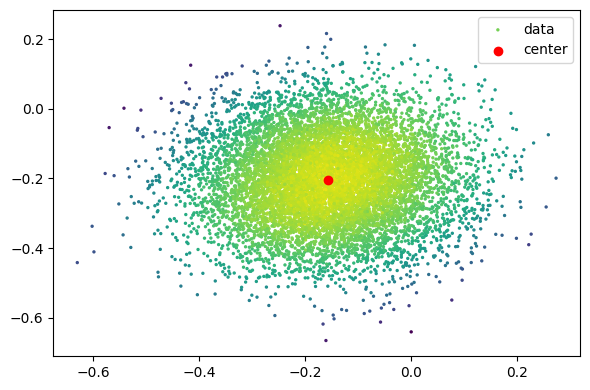

In [7]:
plt.figure(figsize=(6, 4))
plt.scatter(y[:, 0].cpu().numpy(), y[:, 1].cpu().numpy(), label='data', c=densities, cmap='viridis', s=2)
plt.scatter(mean[0].cpu().numpy(), mean[1].cpu().numpy(), color='red', label='center')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
np.quantile(densities, 0.9)

np.float32(2.3642468)

## 2c. Test the likelihood model in obtaining MAP estimates

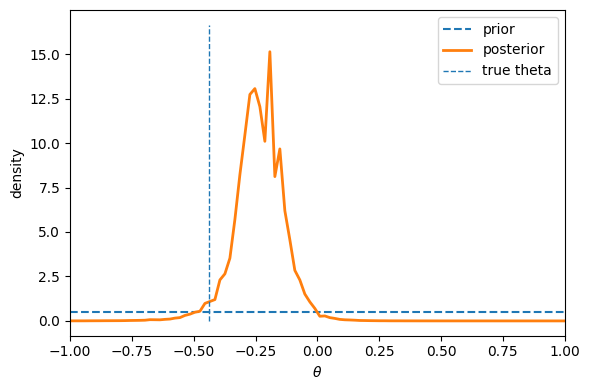

In [9]:
target_theta = torch.linspace(-1, 1, 100).unsqueeze(-1).to(device)
x_history = x.expand(100, 1)
y_history = y[np.random.choice(np.arange(y.shape[0]))].expand(100, 2)
eps_history = eps.expand(100, 1)

proposed_condition = torch.cat([x_history, target_theta, eps_history], dim=1)
ratios = flow_model.estimate_log_density(y_history, proposed_condition, n_steps=10)

grid = np.linspace(-1, 1, 100)

plt.figure(figsize=(6, 4))
plt.plot(grid, np.full_like(grid, 0.5), lw=1.5, ls='--', label='prior')
plt.plot(grid, np.exp(ratios), lw=2.0, label='posterior')
plt.vlines(theta.cpu().numpy(), 0, np.max(np.exp(ratios))*1.1, lw=1.0, ls='--', label='true theta')
plt.xlabel('$\\theta$')
plt.ylabel('density')
plt.xlim(-1, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
mean

tensor([-0.1570, -0.2047], device='cuda:0')

In [11]:
y_history[0]

tensor([ 0.0807, -0.0104], device='cuda:0')

In [12]:
mean - y_history[0]

tensor([-0.2376, -0.1942], device='cuda:0')

## 2d. Test the likelihood model in estimating uncoditional distribution

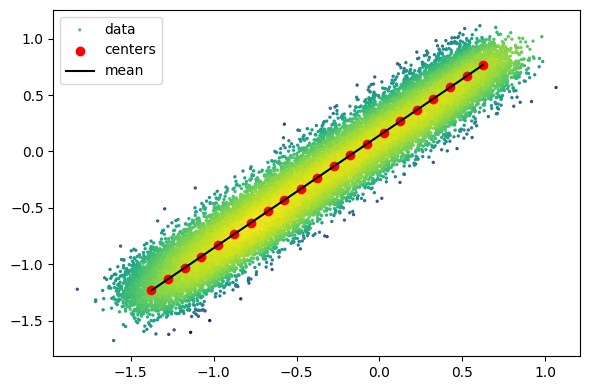

In [13]:
n = 1000
x = (2.0 * torch.rand(x_dim, device=device) - 1.0).expand(n, 1)
eps = (2.0 * torch.rand(eps_dim, device=device) - 1.0).expand(n, 1)

condition = []
y = []
mean = []
# for i in range(25):
    # theta = (2.0 * torch.rand(theta_dim, device=device) - 1.0).expand(n, 1)

for theta in np.arange(-1, 1.1, 0.1):
    theta = torch.tensor(theta, device=device).expand(n, 1).float()
    mean_ = torch.cat([theta + x * eps, theta - x * eps**2], dim=-1)
    
    y.append(mean_ + 0.12 * torch.randn(n, y_dim, device=device))
    condition.append(torch.cat([x, theta, eps], dim=-1))
    mean.append(mean_[0])

y = torch.cat(y, dim=0)
condition = torch.cat(condition, dim=0)
mean = torch.stack(mean)
densities = flow_model.estimate_log_density(y, condition, n_steps=10, use_conds=[True, False, True])

t = np.arange(-1.0, 1.01, 0.01)
z = np.stack([t + x[0].cpu().numpy() * eps[0].cpu().numpy(), t - x[0].cpu().numpy() * eps[0].cpu().numpy()**2]).transpose()

plt.figure(figsize=(6, 4))
plt.scatter(y[:, 0].cpu().numpy(), y[:, 1].cpu().numpy(), label='data', c=densities, cmap='viridis', s=2)
plt.scatter(mean[:, 0].cpu().numpy(), mean[:, 1].cpu().numpy(), color='red', label='centers')
plt.plot(z[:, 0], z[:, 1], label='mean', color='black')
plt.plot()
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
np.quantile(densities, 0.9)

np.float32(0.40243396)

## 3. Train the policy through likelihood gradients

A policy input has shape `(batch, history, features)`: `y_history` has `y_dim` features, `x_history` has `x_dim`, and `eps_history` has `eps_dim`. The flow model is frozen, but gradients are retained with respect to the policy output.

In [15]:
history_length = 3
n_patients = 1024

# Freeze learned density parameters while retaining gradients through its inputs.
for parameter in flow_model.parameters():
    parameter.requires_grad_(False)
flow_model.eval()

def make_patient_batch(n_patients, T, device=device):
    x     = 2.0 * torch.rand(n_patients, 1, x_dim,     device=device) - 1.0
    theta = 2.0 * torch.rand(n_patients, 1, theta_dim, device=device) - 1.0
    eps   = 2.0 * torch.rand(n_patients, T, eps_dim,   device=device) - 1.0

    mean = torch.cat([theta + x * eps, theta - x * eps**2], dim=-1)   # (n, T, y_dim)
    y = mean + 0.12 * torch.randn(n_patients, T, y_dim, device=device)
    return y, x.expand(-1, T, -1), theta.expand(-1, T, -1), eps

policy = BayesianExperimentalDesignPolicy(
    y_dim=y_dim,
    x_dim=x_dim,
    eps_dim=eps_dim,
    hidden_dim=64,
    hidden_dims=[64],
    lr=2e-3,
    eps_min=-1.0,
    eps_max=1.0,
).to(device)

In [16]:
with torch.no_grad():
    y_history, x_history, theta_history, eps_history = make_patient_batch(n_patients, history_length)
    y_history = y_history.reshape(n_patients, history_length, y_dim)
    x_history = x_history.reshape(n_patients, history_length, x_dim)
    eps_history = eps_history.reshape(n_patients, history_length, eps_dim)
    
    x_ = x_history[:, -1]
    theta_ = theta_history.reshape(n_patients, history_length, theta_dim)[:, -1]
    
    proposed_eps = policy(y_history, x_history, eps_history)

proposed_eps[:10]

tensor([[0.0102],
        [0.0354],
        [0.0108],
        [0.0222],
        [0.0152],
        [0.0781],
        [0.0056],
        [0.0334],
        [0.0201],
        [0.0266]], device='cuda:0')

In [17]:
policy_optimizer = torch.optim.Adam(policy.parameters(), lr=policy.lr)
for step in tqdm(range(51)):
    policy_optimizer.zero_grad()

    y_history, x_history, theta_history, eps_history = make_patient_batch(n_patients, history_length)
    y_history = y_history.reshape(n_patients, history_length, y_dim)
    x_history = x_history.reshape(n_patients, history_length, x_dim)
    eps_history = eps_history.reshape(n_patients, history_length, eps_dim)
    
    x_ = x_history[:, -1]
    theta_ = theta_history.reshape(n_patients, history_length, theta_dim)[:, -1]
    
    proposed_eps = policy(y_history, x_history, eps_history)
    proposed_condition = torch.cat([x_, theta_, proposed_eps], dim=1)

    mean = torch.cat([theta_ + x_ * proposed_eps, theta_ - x_ * proposed_eps**2], dim=-1)
    simulated_y = (mean + 0.12 * torch.randn_like(mean, device=device)).detach()
    eig = flow_model.estimate_eig(simulated_y, proposed_condition, n_steps=10)
    
    loss = -eig.mean()
    loss.backward()
    policy_optimizer.step()

    if step % 25 == 0:
        print(f'step={step:03d}, eig={loss.item():.4f}')

  0%|          | 0/51 [00:00<?, ?it/s]

step=000, negative log likelihood=2.0336
step=025, negative log likelihood=1.8922
step=050, negative log likelihood=1.8629


In [18]:
with torch.no_grad():
    y_history, x_history, theta_history, eps_history = make_patient_batch(n_patients, history_length)
    y_history = y_history.reshape(n_patients, history_length, y_dim)
    x_history = x_history.reshape(n_patients, history_length, x_dim)
    eps_history = eps_history.reshape(n_patients, history_length, eps_dim)
    
    x_ = x_history[:, -1]
    theta_ = theta_history.reshape(n_patients, history_length, theta_dim)[:, -1]
    
    proposed_eps = policy(y_history, x_history, eps_history)

proposed_eps[:10]

tensor([[-0.9792],
        [-1.0000],
        [ 0.5199],
        [ 0.8793],
        [-0.1924],
        [ 0.1093],
        [ 0.2210],
        [ 0.0844],
        [ 0.2861],
        [ 0.8176]], device='cuda:0')

## 4. Test the posterior estimation

In [67]:
history_length = 3
n_patients = 1

y_history, x_history, theta_history, eps_history = make_patient_batch(n_patients, history_length + 1)
y_history = y_history.reshape(n_patients, history_length + 1, y_dim)
x_history = x_history.reshape(n_patients, history_length + 1, x_dim)
eps_history = eps_history.reshape(n_patients, history_length + 1, eps_dim)

x_ = x_history[:, -1]
theta_ = theta_history.reshape(n_patients, history_length + 1, theta_dim)[:, -1]

policy.eval()
with torch.no_grad():
    proposed_eps = policy(y_history[:, :-1], x_history[:, :-1], eps_history[:, :-1])
    mean = torch.cat([theta_ + x_ * proposed_eps, theta_ - x_ * proposed_eps**2], dim=-1)
    target_y = mean + 0.12 * torch.randn_like(mean, device=device)

    target_theta = torch.linspace(-1, 1, 100).repeat_interleave(4).unsqueeze(-1).to(device)
    
    y_history[:, -1] = target_y
    y_history = y_history.squeeze(0).repeat(100, 1)
    
    eps_history[:, -1] = proposed_eps
    eps_history = eps_history.squeeze(0).repeat(100, 1)
    
    x_history = x_history.squeeze(0).repeat(100, 1)
    
    proposed_condition = torch.cat([x_history, target_theta, eps_history], dim=1)
    ratios = flow_model.estimate_log_density(y_history, proposed_condition, n_steps=10).reshape(-1, 4)

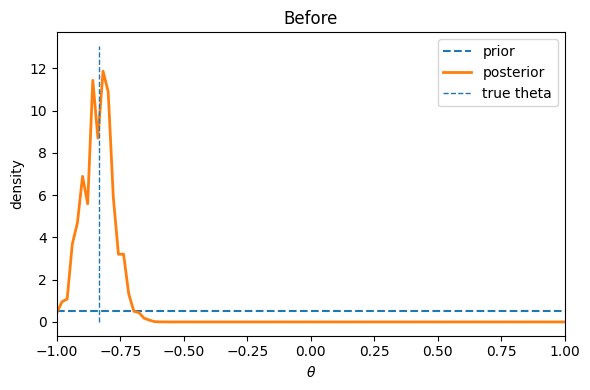

In [68]:
grid = np.linspace(-1, 1, 100)

plt.figure(figsize=(6, 4))
plt.plot(grid, np.full_like(grid, 0.5), lw=1.5, ls='--', label='prior')
plt.plot(grid, np.exp(np.sum(ratios[:, :3], axis=-1)), lw=2.0, label='posterior')
plt.vlines(theta_.cpu().numpy(), 0, np.max(np.exp(np.sum(ratios[:, :3], axis=-1)))*1.1, lw=1.0, ls='--', label='true theta')
plt.xlabel('$\\theta$')
plt.ylabel('density')
plt.xlim(-1, 1)
plt.title("Before")
plt.legend()
plt.tight_layout()
plt.show()

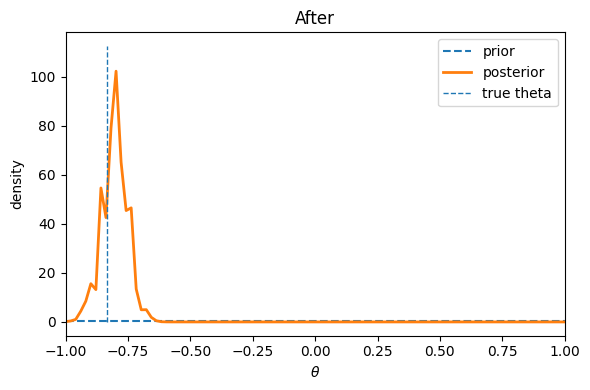

In [69]:
grid = np.linspace(-1, 1, 100)

plt.figure(figsize=(6, 4))
plt.plot(grid, np.full_like(grid, 0.5), lw=1.5, ls='--', label='prior')
plt.plot(grid, np.exp(np.sum(ratios, axis=-1)), lw=2.0, label='posterior')
plt.vlines(theta_.cpu().numpy(), 0, np.max(np.exp(np.sum(ratios, axis=-1)))*1.1, lw=1.0, ls='--', label='true theta')
plt.xlabel('$\\theta$')
plt.ylabel('density')
plt.xlim(-1, 1)
plt.title("After")
plt.legend()
plt.tight_layout()
plt.show()

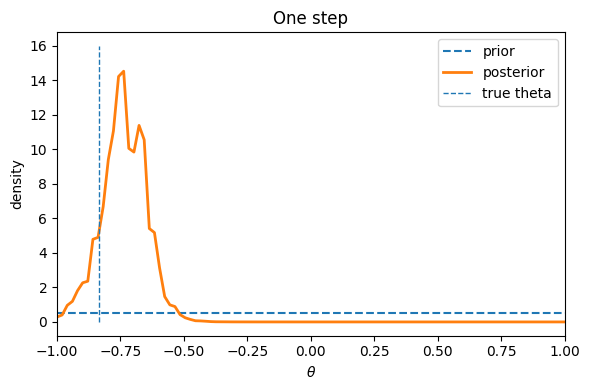

In [70]:
grid = np.linspace(-1, 1, 100)

plt.figure(figsize=(6, 4))
plt.plot(grid, np.full_like(grid, 0.5), lw=1.5, ls='--', label='prior')
plt.plot(grid, np.exp(ratios[:, 3]), lw=2.0, label='posterior')
plt.vlines(theta_.cpu().numpy(), 0, np.max(np.exp(ratios[:, 3]))*1.1, lw=1.0, ls='--', label='true theta')
plt.xlabel('$\\theta$')
plt.ylabel('density')
plt.xlim(-1, 1)
plt.title("One step")
plt.legend()
plt.tight_layout()
plt.show()

In [71]:
theta_

tensor([[-0.8352]], device='cuda:0')

In [72]:
proposed_eps

tensor([[0.4086]], device='cuda:0')